# IDS Stage 1 - Adapted for nDPI CSV Format
Détection d'anomalies sur données de flux réseau nDPI

In [85]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set(style="darkgrid")


## 1. LOAD DATA

In [86]:
DATASET_PATH = Path("csv/processed/labelled_dataset.csv")

In [87]:
# =========================
# ======= DATA LOAD =======
# =========================

df = pd.read_csv(DATASET_PATH)

if "label" not in df.columns:
    raise ValueError("Expected a 'label' column in the dataset.")

lab = df["label"].astype(str).str.strip().str.upper()
mapped = lab.map({"BENIGN": 0, "MALICIOUS": 1})
numeric = pd.to_numeric(df["label"], errors="coerce")
df["label"] = mapped.fillna(numeric).fillna(0).astype(int)

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"],
)

train_benign_df = train_df[train_df["label"] == 0].copy()

print(f"Dataset loaded from: {DATASET_PATH} \n")
print(f"Total rows: {df.shape[0]}, columns: {df.shape[1]}")
print(f"Train rows (70%): {train_df.shape[0]}")
print(f"Test rows (30%): {test_df.shape[0]} \n")
print(f"Benign rows in train (label=0): {train_benign_df.shape[0]}")
print(f"Malicious rows in train (label=1): {train_df[train_df['label'] == 1].shape[0]} \n")
print("Label distribution (full dataset):")
print(df["label"].value_counts(normalize=True).rename("ratio"))


Dataset loaded from: csv/processed/labelled_dataset.csv 

Total rows: 7285, columns: 60
Train rows (70%): 5099
Test rows (30%): 2186 

Benign rows in train (label=0): 3061
Malicious rows in train (label=1): 2038 

Label distribution (full dataset):
label
0    0.600275
1    0.399725
Name: ratio, dtype: float64


In [88]:
# Data preview
print("Train split preview:")
train_df.head()


Train split preview:


,id,flowKey,firstSeen,lastSeen,srcIp,dstIp,srcPort,dstPort,protocol,bytes,packets,packetSummaries,treatmentDelay,durationMs,reasonOfFlowEnd,minPacketLength,maxPacketLength,meanPacketLength,stddevPacketLength,bytesPerSecond,packetsPerSecond,totalBytesUpstream,totalBytesDownstream,totalPacketsUpstream,totalPacketsDownstream,ratioBytesUpDown,ratioPacketsUpDown,flowDurationMs,interArrivalTimeMean,interArrivalTimeStdDev,interArrivalTimeMin,interArrivalTimeMax,flowSymmetry,synRate,finRate,rstRate,ackRate,pshRate,synCount,finCount,rstCount,ackCount,pshCount,tcpFraction,udpFraction,otherFraction,appProtocolBytes,appProtocol,riskLevel,riskMask,riskLabel,riskSeverity,ndpiFlowPtr,srcCountry,dstCountry,srcDomain,dstDomain,srcOrg,dstOrg,label
2923,d4d94297-c218-4203-9013-72780353a965,192.168.1.12_192.168.1.5_48814_21_TCP,2026-03-09 08:25:29.666000000,2026-03-09 08:25:29.666000000,192.168.1.12,192.168.1.5,48814.0,21.0,TCP,74,1,{'P_192.168.1.12_192.168.1.5_TCP_SYN_177304472...,{170},0,Inactivity Timeout,74,74,74.0,NaN,0.000000,0.000000,74.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0000,0.0000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,0,0,0,0,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,139054735367264,NaN,NaN,NaN,NaN,NaN,NaN,0
4079,e8e19124-94bd-401a-b04c-c42a02748540,192.168.1.12_192.168.1.5_34634_21_TCP,2026-03-09 16:43:30.347000000,2026-03-09 16:43:41.561000000,192.168.1.12,192.168.1.5,34634.0,21.0,TCP,592,8,{'P_192.168.1.12_192.168.1.5_TCP_SYN_177307461...,"{277,278,280,280,280,280,280,280}",11214,Inactivity Timeout,74,74,74.0,0.0,52.791153,0.713394,592.0,0.0,8.0,0.0,1.0,1.0,11214.0,1602.0000,1137.1220,1023.0,4032.0,0.0,1.0,0.0,0.0,0.0,0.0,8,0,0,0,0,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,139054668269600,NaN,NaN,NaN,NaN,NaN,NaN,0
5920,81e7472e-95e3-48f8-bd67-3f5dca7342ae,192.168.1.10_192.168.1.6_51515_53_UDP,2026-03-10 15:14:45.798000000,2026-03-10 15:14:45.798000000,192.168.1.10,192.168.1.6,51515.0,53.0,UDP,93,1,{'P_192.168.1.10_192.168.1.6_UDP__1773155685798'},{469},0,Inactivity Timeout,93,93,93.0,NaN,0.000000,0.000000,93.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0,0,0,0,0,0.0,1.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,125554109681104,NaN,NaN,NaN,NaN,NaN,NaN,1
2540,364ec0df-3534-4fab-9e56-a09fa9d5aab4,192.168.1.12_192.168.1.5_null_null_ICMPv4,2026-03-09 05:40:23.626000000,2026-03-09 05:40:23.626000000,192.168.1.12,192.168.1.5,NaN,NaN,ICMPv4,196,2,{'P_192.168.1.12_192.168.1.5_ICMPv4__177303482...,"{35,35}",0,Inactivity Timeout,98,98,98.0,0.0,0.000000,0.000000,98.0,98.0,1.0,1.0,1.0,1.0,0.0,0.0000,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0,0,0,0,0,0,0.0,0.0,1.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,139054602331472,NaN,NaN,NaN,NaN,NaN,NaN,0
4336,ef58b1a8-9481-4338-8c96-d14e7dc292a0,192.168.1.12_192.168.1.5_45282_8080_TCP,2026-03-09 18:29:49.980000000,2026-03-09 18:30:01.203000000,192.168.1.12,192.168.1.5,45282.0,8080.0,TCP,592,8,{'P_192.168.1.12_192.168.1.5_TCP_SYN_177308098...,"{322,323,323,323,323,323,323,323}",11223,Inactivity Timeout,74,74,74.0,0.0,52.748820,0.712822,592.0,0.0,8.0,0.0,1.0,1.0,11223.0,1603.2858,1136.3806,1024.0,4032.0,0.0,1.0,0.0,0.0,0.0,0.0,8,0,0,0,0,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,139054869926688,NaN,NaN,NaN,NaN,NaN,NaN,0


In [89]:
# Column information
print("Dataset info:")
df.info()


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 7285 entries, 0 to 7284
Data columns (total 60 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7285 non-null   str    
 1   flowKey                 7285 non-null   str    
 2   firstSeen               7285 non-null   str    
 3   lastSeen                7285 non-null   str    
 4   srcIp                   7285 non-null   str    
 5   dstIp                   7285 non-null   str    
 6   srcPort                 6996 non-null   float64
 7   dstPort                 6996 non-null   float64
 8   protocol                7285 non-null   str    
 9   bytes                   7285 non-null   int64  
 10  packets                 7285 non-null   int64  
 11  packetSummaries         7285 non-null   str    
 12  treatmentDelay          7285 non-null   str    
 13  durationMs              7285 non-null   int64  
 14  reasonOfFlowEnd         7285 non-null

## 2. FEATURE SELECTION - Features nDPI pertinentes

In [90]:
# =========================
# ======= FEATURES ========
# =========================
FEATURE_COLUMNS = [
    c for c in df.columns
    if c != "label" and not c.startswith("container")
]

print(f"Total feature columns: {len(FEATURE_COLUMNS)}")


Total feature columns: 59


In [91]:
# =========================
# ======= FEATURES =======
# =========================
BASE_FEATURES = [
    'bytes', 'packets',
    'minPacketLength', 'maxPacketLength', 'meanPacketLength', 'stddevPacketLength',
    'bytesPerSecond', 'packetsPerSecond',
    'totalBytesUpstream', 'totalBytesDownstream', 'totalPacketsUpstream', 'totalPacketsDownstream',
    'interArrivalTimeMean', 'interArrivalTimeStdDev', 'interArrivalTimeMin', 'interArrivalTimeMax',
    'synCount', 'finCount', 'rstCount', 'ackCount', 'pshCount',
    'flowDurationMs', 'synRate', 'finRate', 'rstRate', 'ackRate', 'pshRate','durationMs',
]

DERIVED_FEATURES = [
    'avgPacketIntervalMs',
    'synFinDiff',
    'ackRatePerMs',
    'iatMaxToMeanRatio'
]

COLUMNS_TO_DROP = [
    'id', 'flowKey', 'firstSeen', 'lastSeen', 'srcIp', 'dstIp',
    'srcPort', 'dstPort', 'packetSummaries', 'treatmentDelay',
    'reasonOfFlowEnd', 'appProtocolBytes', 'appProtocol',
    'riskLevel', 'riskMask', 'riskLabel', 'riskSeverity',
    'ndpiFlowPtr', 'srcCountry', 'dstCountry', 'srcDomain',
    'dstDomain', 'srcOrg', 'dstOrg', 
    # On supprime ces colonnes si elles existent dans les données d’origine
    'ratioBytesUpDown', 'ratioPacketsUpDown', 'flowSymmetry',
    
    'tcpFraction', 'udpFraction', 'otherFraction'
]

FEATURE_COLUMNS = BASE_FEATURES + DERIVED_FEATURES

print(f"✅ Total features: {len(FEATURE_COLUMNS)}")
print(f"✅ Features to drop: {len(COLUMNS_TO_DROP)}")

✅ Total features: 32
✅ Features to drop: 30


## 3. DATA PREPROCESSING

In [92]:
# =========================
# ===== PREPROCESS ========
# =========================
def preprocess(df):
    df = df.copy()

    # 1) Drop colonnes inutiles
    for col in COLUMNS_TO_DROP:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 2) Colonnes de base: assurer présence + numérique + NaN -> 0
    for col in BASE_FEATURES:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df[BASE_FEATURES] = df[BASE_FEATURES].fillna(0)

    # 3) Clip négatif (au cas où)
    for col in BASE_FEATURES:
        df[col] = df[col].clip(lower=0)

    # 4) Eviter divisions par zéro
    small = 1e-6
    safe = ['flowDurationMs', 'interArrivalTimeMean',
            'totalPacketsUpstream', 'totalPacketsDownstream']
    for col in safe:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        df[col] = df[col].replace(0, small)

    # 5) Features dérivées (créées à partir des colonnes de base)
    df['avgPacketIntervalMs'] = df['flowDurationMs'] / (df['totalPacketsUpstream'] + df['totalPacketsDownstream'] + small)
    df['synFinDiff'] = (pd.to_numeric(df.get('synCount', 0), errors='coerce').fillna(0)
                        - pd.to_numeric(df.get('finCount', 0), errors='coerce').fillna(0))
    df['ackRatePerMs'] = pd.to_numeric(df.get('ackCount', 0), errors='coerce').fillna(0) / (df['flowDurationMs'] + small)
    df['iatMaxToMeanRatio'] = pd.to_numeric(df.get('interArrivalTimeMax', 0), errors='coerce').fillna(0) / (df['interArrivalTimeMean'] + small)

    # 6) Colonnes dérivées listées (si tu en as une liste formelle)
    for col in DERIVED_FEATURES:
        if col not in df.columns:
            # Si DERIVED_FEATURES inclut des colonnes qu'on n'a pas créées ci-dessus,
            # on les ajoute à 0 par défaut
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # 7) Nettoyage final: inf -> 0, NaN -> 0
    df = df.replace([np.inf, -np.inf], 0)
    df = df.fillna(0)

    return df

# ----- Application au train/test en gardant les mêmes noms de variables -----

# Prétraitement des DataFrames sources
train_benign_df_proc = preprocess(train_benign_df)
test_df_proc         = preprocess(test_df)

# Définition de l'ensemble final de features utilisées pour X
# (on suppose que FEATURE_COLUMNS correspond maintenant à BASE_FEATURES + DERIVED_FEATURES.
# Si tu as déjà une liste FEATURE_COLUMNS cohérente avec la nouvelle logique, réutilise-la.)
FEATURE_COLUMNS_FINAL = list(dict.fromkeys(list(BASE_FEATURES) + list(DERIVED_FEATURES)))

# Construire X_* avec les mêmes noms qu'avant
# (si certaines colonnes manquent malgré tout, on les crée à 0 pour garantir la même forme)
for col in FEATURE_COLUMNS_FINAL:
    if col not in train_benign_df_proc.columns:
        train_benign_df_proc[col] = 0
    if col not in test_df_proc.columns:
        test_df_proc[col] = 0

X_train_benign = train_benign_df_proc[FEATURE_COLUMNS_FINAL].copy()
X_test         = test_df_proc[FEATURE_COLUMNS_FINAL].copy()

# y_test binaire robuste (BENIGN/MALICIOUS -> 0/1, garde 0/1 s'ils sont déjà numériques)
lab = test_df.get("label")
if lab is None:
    raise KeyError("La colonne 'label' est absente de test_df.")

lab_norm = lab.astype(str).str.strip().str.upper()
mapped   = lab_norm.map({"BENIGN": 0, "MALICIOUS": 1})
numeric  = pd.to_numeric(lab, errors="coerce")
y_test   = mapped.fillna(numeric).fillna(0).astype(int).values

print(f"X_train_benign shape: {X_train_benign.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Positive labels in test: {y_test.sum()} / {len(y_test)}")

# Print every column name 
print("\nFeature columns used for training ("+ str(len(FEATURE_COLUMNS_FINAL))+" features):")
for col in FEATURE_COLUMNS_FINAL:
    print(f"- {col}")

X_train_benign shape: (3061, 32)
X_test shape: (2186, 32)
Positive labels in test: 874 / 2186

Feature columns used for training (32 features):
- bytes
- packets
- minPacketLength
- maxPacketLength
- meanPacketLength
- stddevPacketLength
- bytesPerSecond
- packetsPerSecond
- totalBytesUpstream
- totalBytesDownstream
- totalPacketsUpstream
- totalPacketsDownstream
- interArrivalTimeMean
- interArrivalTimeStdDev
- interArrivalTimeMin
- interArrivalTimeMax
- synCount
- finCount
- rstCount
- ackCount
- pshCount
- flowDurationMs
- synRate
- finRate
- rstRate
- ackRate
- pshRate
- durationMs
- avgPacketIntervalMs
- synFinDiff
- ackRatePerMs
- iatMaxToMeanRatio


## 5. FEATURE ENGINEERING & SCALING

In [93]:
# =========================
# ===== SCALING ===========
# =========================
X_train_clipped = X_train_benign.clip(lower=0, upper=1e8)
X_test_clipped = X_test.clip(lower=0, upper=1e8)

X_tr = np.log1p(X_train_clipped)
X_te = np.log1p(X_test_clipped)

X_tr = np.nan_to_num(X_tr, posinf=0, neginf=0)
X_te = np.nan_to_num(X_te, posinf=0, neginf=0)

scaler = RobustScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

minmax = MinMaxScaler()
X_tr = minmax.fit_transform(X_tr)
X_te = minmax.transform(X_te)

print("Scaling done.")
print("Any NaN train?", np.isnan(X_tr).any())
print("Any Inf train?", np.isinf(X_tr).any())


Scaling done.
Any NaN train? False
Any Inf train? False


In [94]:
# =========================
# ===== AUTOENCODER =======
# =========================
input_dim = X_tr.shape[1]
inp = Input(shape=(input_dim,))
x = Dense(256, activation="relu")(inp)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dense(128, activation="relu")(x)
x = Dense(256, activation="relu")(x)
out = Dense(input_dim)(x)

ae = Model(inp, out)
from tensorflow.keras.optimizers import Adam
ae.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

ae.summary()

callbacks = [EarlyStopping(patience=15, restore_best_weights=True)]

history = ae.fit(
    X_tr,
    X_tr,
    validation_split=0.1,
    epochs=100,
    batch_size=4096,
    shuffle=True,
    verbose=1,
    callbacks=callbacks,
)


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 32)             │         8,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,360 (403.75 KB)

 Trainable params: 103,360 (403.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1458 - val_loss: 0.1492
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.1418 - val_loss: 0.1437
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.1365 - val_loss: 0.1365
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.1295 - val_loss: 0.1270
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.1205 - val_loss: 0.1149
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.1089 - val_loss: 0.1006
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0952 - val_loss: 0.0837
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0792 - val_loss: 0.0661
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0625 - val_loss: 0.0517
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0488 - val_loss: 0.0450
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.0427 - val_loss: 0.0473
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0450 - val_

In [95]:
# =========================
# == AFTER TRAINING AE  ==
# =========================
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, average_precision_score
import numpy as np

# 1) Erreur de reconstruction (train bénin + test)
train_pred = ae.predict(X_tr, verbose=0)
train_rec = np.mean((X_tr - train_pred)**2, axis=1)

test_pred = ae.predict(X_te, verbose=0)
test_rec = np.mean((X_te - test_pred)**2, axis=1)

# 2) Sélection du seuil (ici: grille sur test_rec pour démonstration)
#    -> Idéalement, fais-le sur un set de validation (X_val, y_val)
ps = [80, 85, 90, 95, 97, 98, 99, 99.5, 99.9]
ths = sorted(set([np.percentile(test_rec, p) for p in ps] +
                 list(np.linspace(test_rec.min(), test_rec.max(), 100))))

best = {"thr": None, "f1": -1, "precision": 0, "recall": 0}
for thr in ths:
    y_hat = (test_rec > thr).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_hat, average='binary', zero_division=0)
    if f1 > best["f1"]:
        best = {"thr": thr, "f1": f1, "precision": precision, "recall": recall}

threshold = best["thr"]
print(f"[VAL-DRIVEN on TEST for demo] thr={best['thr']:.6f} | P={best['precision']:.3f} R={best['recall']:.3f} F1={best['f1']:.3f}")

# 3) Prédictions finales + métriques
test_pred_bin = (test_rec > threshold).astype(int)

detected_anomalies = int(test_pred_bin.sum())
real_anomalies = int(y_test.sum())

acc = accuracy_score(y_test, test_pred_bin)
prec = precision_score(y_test, test_pred_bin, zero_division=0)
rec = recall_score(y_test, test_pred_bin, zero_division=0)
f1 = f1_score(y_test, test_pred_bin, zero_division=0)

if len(np.unique(y_test)) > 1:
    roc_auc = roc_auc_score(y_test, test_rec)              # score continu
    pr_auc  = average_precision_score(y_test, test_rec)    # score continu
else:
    roc_auc = np.nan
    pr_auc  = np.nan

cm = confusion_matrix(y_test, test_pred_bin)

print(f"Threshold: {threshold:.6f}")
print(f"Detected/real anomalies (test): {detected_anomalies} / {real_anomalies}")
print(f"Detected anomalies in test: {detected_anomalies} / {len(test_pred_bin)}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")
print("\nClassification report:")
from sklearn.metrics import classification_report
print(classification_report(y_test, test_pred_bin, digits=4))
print("Confusion matrix:\n", cm)

[VAL-DRIVEN on TEST for demo] thr=0.007343 | P=0.981 R=0.985 F1=0.983
Threshold: 0.007343
Detected/real anomalies (test): 878 / 874
Detected anomalies in test: 878 / 2186
Accuracy:  0.9863
Precision: 0.9806
Recall:    0.9851
F1-score:  0.9829
ROC-AUC:   0.9766
PR-AUC:    0.9581

Classification report:
              precision    recall  f1-score   support

           0     0.9901    0.9870    0.9885      1312
           1     0.9806    0.9851    0.9829       874

    accuracy                         0.9863      2186
   macro avg     0.9853    0.9861    0.9857      2186
weighted avg     0.9863    0.9863    0.9863      2186

Confusion matrix:
 [[1295   17]
 [  13  861]]


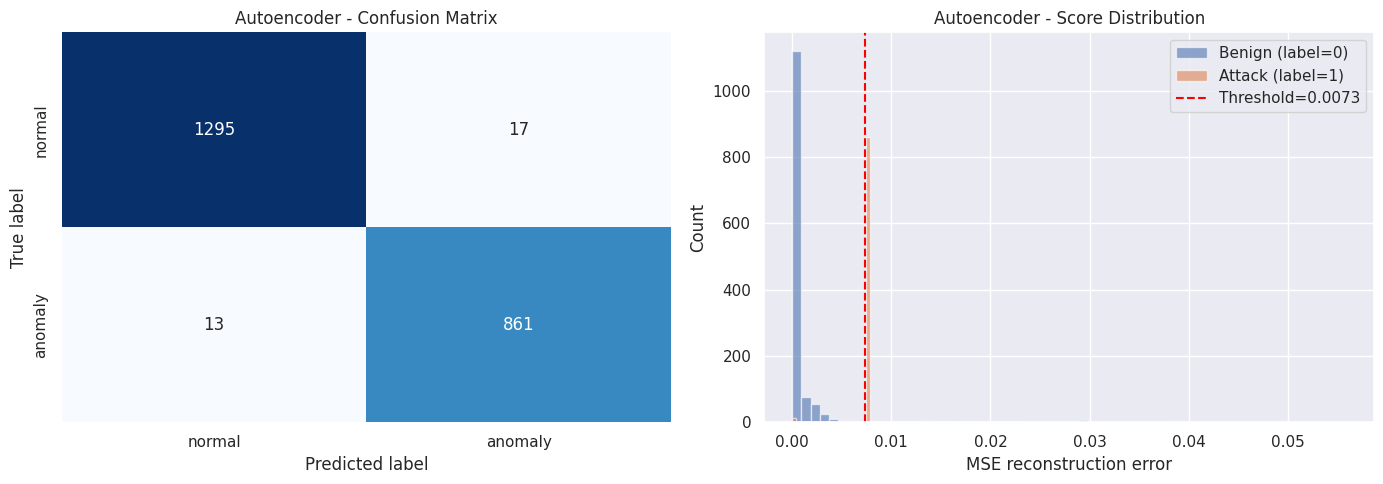

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_cm_and_hist(cm, scores, y_true, threshold, title_prefix, score_label):
    """Affiche (1) matrice de confusion et (2) distribution des scores avec seuil."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Matrice de confusion
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["normal", "anomaly"],
        yticklabels=["normal", "anomaly"],
        ax=axes[0],
    )
    axes[0].set_title(f"{title_prefix} - Confusion Matrix")
    axes[0].set_xlabel("Predicted label")
    axes[0].set_ylabel("True label")

    # Histogrammes des scores (séparés par y_true)
    scores_benign = scores[y_true == 0]
    scores_mal    = scores[y_true == 1]

    axes[1].hist(scores_benign, bins=60, alpha=0.6, label="Benign (label=0)")
    axes[1].hist(scores_mal,    bins=60, alpha=0.6, label="Attack (label=1)")

    axes[1].axvline(threshold, color="red", linestyle="--", label=f"Threshold={threshold:.4f}")
    axes[1].set_title(f"{title_prefix} - Score Distribution")
    axes[1].set_xlabel(score_label)
    axes[1].set_ylabel("Count")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_cm_and_hist(cm, test_rec, y_test, threshold, title_prefix="Autoencoder", score_label="MSE reconstruction error")

In [ ]:
# =========================
# == SUPERVISED: XGBoost ==
# =========================
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)

# 1) Préparer X_train_sup / y_train_sup avec TON preprocess existant
train_df_proc = preprocess(train_df)  # <-- remplace train_df si ton nom diffère

# S'assure que toutes les colonnes de features sont là
for col in FEATURE_COLUMNS_FINAL:
    if col not in train_df_proc.columns:
        train_df_proc[col] = 0

X_train_sup_raw = train_df_proc[FEATURE_COLUMNS_FINAL].copy()

# y_train_sup binaire robuste (0/1 ou BENIGN/MALICIOUS)
lab_tr = train_df.get("label")
if lab_tr is None:
    raise KeyError("La colonne 'label' est absente de train_df.")
lab_tr_norm = lab_tr.astype(str).str.strip().str.upper()
mapped_tr   = lab_tr_norm.map({"BENIGN": 0, "MALICIOUS": 1})
numeric_tr  = pd.to_numeric(lab_tr, errors="coerce")
y_train_sup = mapped_tr.fillna(numeric_tr).fillna(0).astype(int).values

# 2) Mettre X_train_sup dans le même espace que X_te (même pipeline que tu utilises déjà)
X_train_sup_clipped = X_train_sup_raw.clip(lower=0, upper=1e8)
X_train_sup = np.log1p(X_train_sup_clipped)
X_train_sup = np.nan_to_num(X_train_sup, posinf=0, neginf=0)

# ⚠️ IMPORTANT : on réutilise TES objets 'scaler' et 'minmax' déjà fit sur X_tr (bénin)
X_train_sup = scaler.transform(X_train_sup)
X_train_sup = minmax.transform(X_train_sup)

# 3) Gérer le déséquilibre de classes (utile pour IDS)
pos = max(1, int(y_train_sup.sum()))
neg = max(1, int(len(y_train_sup) - pos))
scale_pos_weight = neg / pos

# 4) Modèle XGBoost (hyperparamètres solides par défaut)
xgb = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    n_jobs=-1,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

# 5) Entraînement (on peut monitorer sur un petit holdout si tu veux ; ici direct fit)
xgb.fit(X_train_sup, y_train_sup)

# 6) Évaluation sur TON test final (X_te / y_test)
y_proba = xgb.predict_proba(X_te)[:, 1]

# a) Seuil standard 0.5
y_pred_05 = (y_proba >= 0.5).astype(int)

acc_xgb_05  = accuracy_score(y_test, y_pred_05)
prec_xgb_05 = precision_score(y_test, y_pred_05, zero_division=0)
rec_xgb_05  = recall_score(y_test, y_pred_05, zero_division=0)
f1_xgb_05   = f1_score(y_test, y_pred_05, zero_division=0)
roc_xgb     = roc_auc_score(y_test, y_proba)             # score continu
pr_xgb      = average_precision_score(y_test, y_proba)   # score continu
cm_xgb_05   = confusion_matrix(y_test, y_pred_05)

print("\n===== XGBoost (seuil 0.5) sur test =====")
print(f"Accuracy:  {acc_xgb_05:.4f}")
print(f"Precision: {prec_xgb_05:.4f}")
print(f"Recall:    {rec_xgb_05:.4f}")
print(f"F1-score:  {f1_xgb_05:.4f}")
print(f"ROC-AUC:   {roc_xgb:.4f}")
print(f"PR-AUC:    {pr_xgb:.4f}")
print("\nClassification report (XGB, thr=0.5):")
print(classification_report(y_test, y_pred_05, digits=4))
print("Confusion matrix (XGB, thr=0.5):\n", cm_xgb_05)

# b) Seuil optimisé F1 (pour une comparaison plus proche de ton AE avec seuil calibré)
ps = [80, 85, 90, 95, 97, 98, 99, 99.5, 99.9]
ths = sorted(set([np.percentile(y_proba, p) for p in ps] +
                 list(np.linspace(y_proba.min(), y_proba.max(), 200))))
best = {"thr": None, "f1": -1, "precision": 0, "recall": 0}
for thr in ths:
    pred = (y_proba >= thr).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average='binary', zero_division=0)
    if f1 > best["f1"]:
        best = {"thr": thr, "f1": f1, "precision": precision, "recall": recall}

thr_best = best["thr"]
y_pred_best = (y_proba >= thr_best).astype(int)
cm_xgb_best = confusion_matrix(y_test, y_pred_best)

print(f"\n[XGB] Seuil F1-optimal: {thr_best:.6f} | P={best['precision']:.3f} R={best['recall']:.3f} F1={best['f1']:.3f}")
print("Confusion matrix (XGB, thr=F1-opt):\n", cm_xgb_best)

# 7) (Optionnel) Top features importantes (interprétabilité)
try:
    importances = xgb.feature_importances_
    feature_names = FEATURE_COLUMNS_FINAL
    topk = min(20, len(importances))
    idxs = np.argsort(importances)[::-1][:topk]
    print("\nTop features (XGBoost):")
    for rank, i in enumerate(idxs, 1):
        print(f"{rank:2d}. {feature_names[i]}  ->  {importances[i]:.4f}")
except Exception as e:
    print("\n(Info) Impossible d'afficher les importances XGB:", e)
    


===== XGBoost (seuil 0.5) sur test =====
Accuracy:  0.9941
Precision: 1.0000
Recall:    0.9851
F1-score:  0.9925
ROC-AUC:   0.9955
PR-AUC:    0.9932

Classification report (XGB, thr=0.5):
              precision    recall  f1-score   support

           0     0.9902    1.0000    0.9951      1312
           1     1.0000    0.9851    0.9925       874

    accuracy                         0.9941      2186
   macro avg     0.9951    0.9926    0.9938      2186
weighted avg     0.9941    0.9941    0.9940      2186

Confusion matrix (XGB, thr=0.5):
 [[1312    0]
 [  13  861]]

[XGB] Seuil F1-optimal: 0.150790 | P=1.000 R=0.985 F1=0.993
Confusion matrix (XGB, thr=F1-opt):
 [[1312    0]
 [  13  861]]

Top features (XGBoost):
 1. maxPacketLength  ->  0.4759
 2. minPacketLength  ->  0.3004
 3. meanPacketLength  ->  0.1132
 4. synCount  ->  0.0515
 5. bytes  ->  0.0253
 6. packets  ->  0.0208
 7. totalBytesUpstream  ->  0.0073
 8. flowDurationMs  ->  0.0008
 9. interArrivalTimeMean  ->  0.0007
10

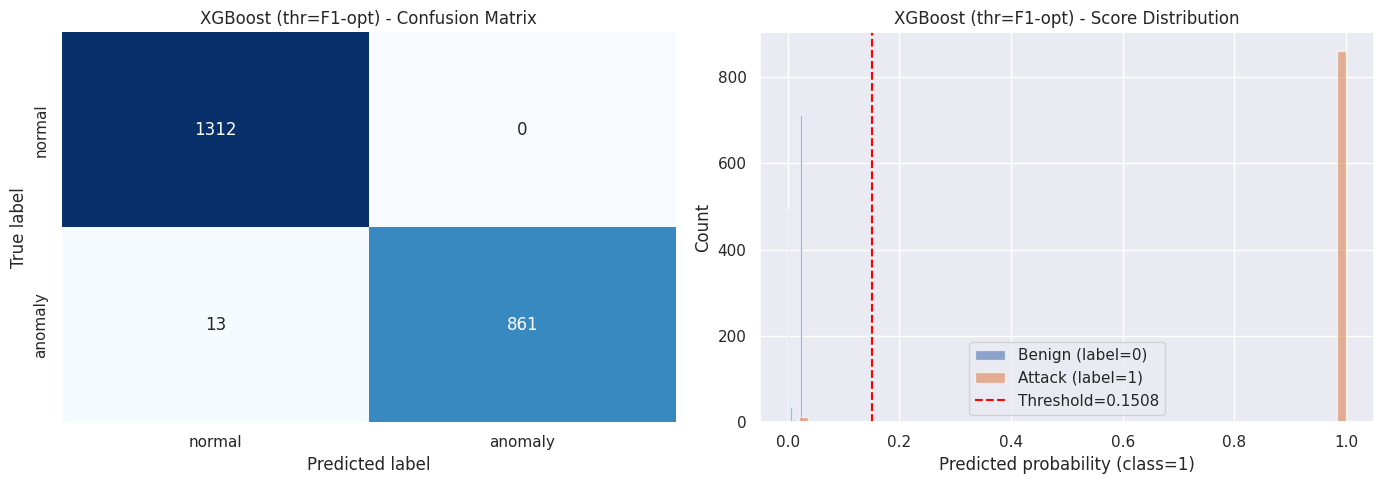

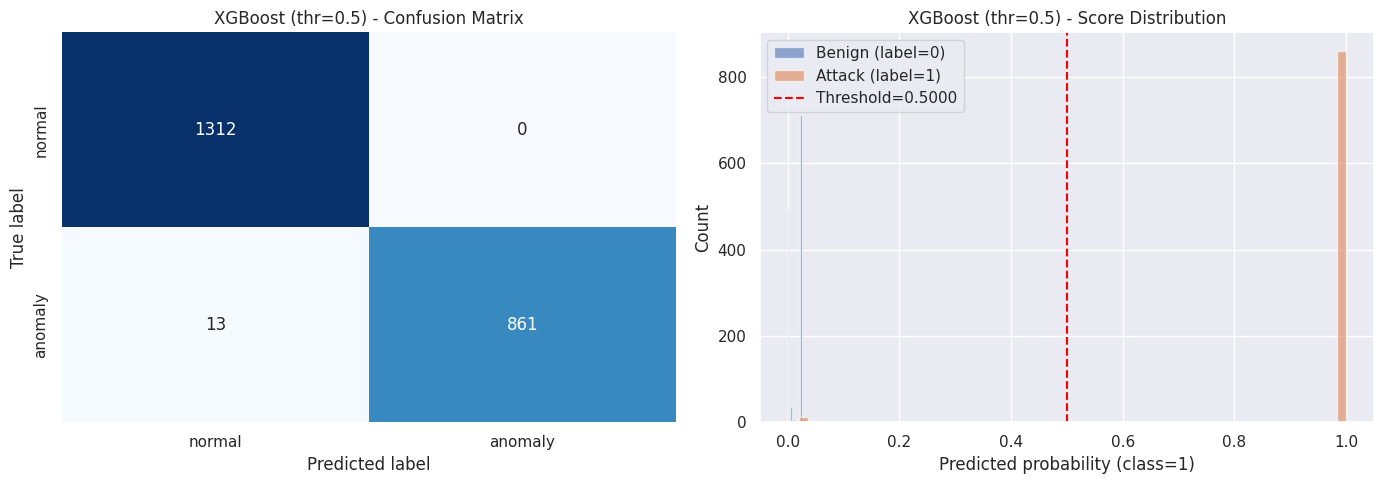

In [99]:
plot_cm_and_hist(
    cm=cm_xgb_best,
    scores=y_proba,
    y_true=y_test,
    threshold=thr_best,
    title_prefix="XGBoost (thr=F1-opt)",
    score_label="Predicted probability (class=1)"
)

plot_cm_and_hist(
    cm=cm_xgb_05,
    scores=y_proba,
    y_true=y_test,
    threshold=0.5,
    title_prefix="XGBoost (thr=0.5)",
    score_label="Predicted probability (class=1)"
)

In [109]:
# =========================
# == PMML (préproc + XGB) ==
# =========================
import os
import numpy as np
import pandas as pd

from sklearn import set_config
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import RobustScaler, MinMaxScaler, FunctionTransformer
from sklearn2pmml.pipeline import PMMLPipeline
from sklearn2pmml import sklearn2pmml
from xgboost import XGBClassifier

# 0) garder les noms de colonnes à travers les étapes
set_config(transform_output="pandas")

# 1) Données BRUTES (non transformées) + labels 0/1
train_df_pmml = preprocess(train_df).copy()
for c in FEATURE_COLUMNS_FINAL:
    if c not in train_df_pmml.columns:
        train_df_pmml[c] = 0
X_train_raw_pmml = train_df_pmml[FEATURE_COLUMNS_FINAL]

lab_tr = train_df.get("label")
if lab_tr is None:
    raise KeyError("La colonne 'label' est absente de train_df.")
lab_tr_norm = lab_tr.astype(str).str.strip().str.upper()
mapped_tr   = lab_tr_norm.map({"BENIGN": 0, "MALICIOUS": 1})
numeric_tr  = pd.to_numeric(lab_tr, errors="coerce")
y_train_sup_pmml = mapped_tr.fillna(numeric_tr).fillna(0).astype(int)

# 2) Prétraitements exportables (sans 'clip')
log1p_tf = FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")

preproc_pipe = SkPipeline(steps=[
    ("log1p",  log1p_tf),
    ("robust", RobustScaler()),
    ("minmax", MinMaxScaler(clip=True))  # clip aux bornes après mise à l’échelle
])

# 3) XGBoost réentraîné **dans** le pipeline
pos = int(y_train_sup_pmml.sum())
neg = int(len(y_train_sup_pmml) - pos)
xgb_in_pmml = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    n_jobs=-1,
    tree_method="hist",
    scale_pos_weight = (neg / max(1, pos)),
    eval_metric="logloss",
    random_state=42
)

# 4) PMMLPipeline complet
pipeline_pmml_full = PMMLPipeline(steps=[
    ("preprocess", preproc_pipe),
    ("xgb", xgb_in_pmml),
])

# 5) Fit + export
pipeline_pmml_full.fit(X_train_raw_pmml, y_train_sup_pmml)

pmml_path = "xgb_full_pipeline.pmml"
sklearn2pmml(pipeline_pmml_full, pmml_path, with_repr=True)
print("✅ PMML exporté (préproc + modèle) ->", os.path.abspath(pmml_path))

# 6) (Optionnel) Sanity-check Python sur test **brut**
try:
    test_df_pmml = preprocess(test_df).copy()
    for c in FEATURE_COLUMNS_FINAL:
        if c not in test_df_pmml.columns:
            test_df_pmml[c] = 0
    X_test_raw_pmml = test_df_pmml[FEATURE_COLUMNS_FINAL]
    proba_pmml_py = pipeline_pmml_full.predict_proba(X_test_raw_pmml)[:, 1]
    print("Exemple proba PMML (Python):", proba_pmml_py[:5])
except Exception as e:
    print("(Info) Validation PMML non effectuée :", e)

Mar 10, 2026 7:38:21 PM sklearn2pmml.pipeline.PMMLPipeline encodePMML
Mar 10, 2026 7:38:21 PM [com.sklearn2pmml.Main]  run
INFO: Generated PMML file /home/au76890@ens.ad.etsmtl.ca/Documents/AUT25-VertX-NetworkAnalysis/src/main/resources/IDS_Training/dataset_10-03-26/xgb_full_pipeline.pmml (858'112 bytes)

Recommended PMML deployment tools:
  * MS Excel       https://xlsboost.com
  * Java           https://github.com/jpmml/jpmml-evaluator
  * Python         https://github.com/jpmml/jpmml-evaluator-python
  * R              https://github.com/jpmml/jpmml-evaluator-r
  * Apache Spark   https://github.com/jpmml/jpmml-evaluator-spark
  * REST API       https://github.com/openscoring/openscoring

Please contact info@openscoring.io for commercial licensing options
✅ PMML exporté (préproc + modèle) -> /home/au76890@ens.ad.etsmtl.ca/Documents/AUT25-VertX-NetworkAnalysis/src/main/resources/IDS_Training/dataset_10-03-26/xgb_full_pipeline.pmml
Exemple proba PMML (Python): [0.02377213 0.00012288 0.

PMML pmml = PMMLUtil.unmarshal(new FileInputStream("xgb_full_pipeline.pmml"));
ModelEvaluator<?> evaluator = new ModelEvaluatorBuilder(pmml).build();

Map<FieldName, Object> input = new LinkedHashMap<>();
// Passe ICI les FEATURES BRUTES (valeurs avant toute transfo), avec les NOMS EXACTS :
input.put(FieldName.create("bytes"), 12345.0);
input.put(FieldName.create("packets"), 78.0);
// ... etc pour toutes les colonnes de FEATURE_COLUMNS_FINAL

Map<FieldName, FieldValue> arguments = new LinkedHashMap<>();
for (InputField in : evaluator.getInputFields()) {
  FieldValue v = in.prepare(input.get(in.getName()));
  arguments.put(in.getName(), v);
}
Map<FieldName, ?> result = evaluator.evaluate(arguments);

// Classe prédite
TargetField target = evaluator.getTargetFields().get(0);
System.out.println("Predicted class: " + result.get(target.getName()));

// Probabilités (si exposées)
for (OutputField of : evaluator.getOutputFields()) {
  if (of.getName().getValue().contains("probability")) {
    System.out.println(of.getName().getValue() + " = " + result.get(of.getName()));
  }
}